# Breast Cancer Classification — Pretrained ResNet-18 + Uncertainty + Grad-CAM

Transfer-learning baseline (CBIS-DDSM full mammograms) with:
- Patient-grouped stratified validation split (no leakage).
- Comprehensive post-training evaluation (AUROC, sensitivity/specificity, PPV/NPV, MCC, ROC, PR).
- **Monte-Carlo dropout uncertainty**: dropout kept active at inference, BN in eval, T stochastic passes.
- **Grad-CAM** on the last convolutional block for spatial interpretability.


In [5]:
import os, random, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [6]:
import numpy as np, pandas as pd
from pathlib import Path
from PIL import Image, ImageOps
from skimage.filters import threshold_otsu
from scipy import ndimage as ndi

SRC = Path('/kaggle/input/datasets/muhammadsufyan0/datasettt/Breast_Cancer_Final_1024')
DST = Path('/kaggle/working/Breast_Cancer_Final_Masked')
SIZE = 1024

def preprocess_masked(a, size=1024, feather=11):
    mask = ndi.binary_fill_holes(a > threshold_otsu(a))
    lbl, n = ndi.label(mask)
    if n:
        biggest = 1 + int(np.argmax(ndi.sum(np.ones_like(lbl), lbl, range(1, n+1))))
        keep = lbl == biggest
        soft = ndi.gaussian_filter(keep.astype(np.float32), sigma=feather)
        soft = np.clip((soft - 0.2) / 0.6, 0, 1)          # feathered 0..1 edge
        a = (a * soft).astype(a.dtype)
        ys, xs = np.where(keep)
        a = a[ys.min():ys.max()+1, xs.min():xs.max()+1]
        soft_c = soft[ys.min():ys.max()+1, xs.min():xs.max()+1]  # (keep if you want to inspect)
    return np.asarray(ImageOps.pad(Image.fromarray(a), (size, size), method=Image.LANCZOS, color=0))

def run(split):
    df = pd.read_csv(SRC / f'{split}.csv')
    for fn in df['filename']:
        dst = DST / split / fn
        dst.parent.mkdir(parents=True, exist_ok=True)
        a = np.asarray(Image.open(SRC / split / fn).convert('L'))
        Image.fromarray(preprocess_masked(a)).save(dst)
    df['filepath'] = str(DST) + f'/{split}/' + df['filename']
    df.to_csv(DST / f'{split}.csv', index=False)
    print(f'{split}: {len(df)} masked images written, csv updated')

run('train')
run('test')

train: 1164 masked images written, csv updated
test: 299 masked images written, csv updated


In [7]:
DATA_DIR   = '/kaggle/working/Breast_Cancer_Final_Masked'
IMG_SIZE   = 1024
BATCH_SIZE = 16
EPOCHS     = 10
PATIENCE   = 6
FOLDS      = 2
LR_BACKBONE, LR_HEAD = 1e-4, 1e-3
WEIGHT_DECAY = 1e-3
DROPOUT_P  = 0.5
ATT_DIM    = 128
MC_PASSES  = 30
WORK = '/kaggle/working'
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedGroupKFold
train_full = pd.read_csv(f"{DATA_DIR}/train.csv")
test_df    = pd.read_csv(f"{DATA_DIR}/test.csv")

train_full["filepath"] = DATA_DIR + "/train/" + train_full["filename"]
test_df["filepath"]    = DATA_DIR + "/test/"  + test_df["filename"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
tr_idx, va_idx = next(sgkf.split(train_full, train_full["label"], groups=train_full["patient_id"]))
train_df = train_full.iloc[tr_idx].reset_index(drop=True)
val_df   = train_full.iloc[va_idx].reset_index(drop=True)
assert len(set(train_df.patient_id) & set(val_df.patient_id)) == 0
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 931
Validation: 233
Test: 299


### Patient-grouped, stratified train/val split
Guarantees no patient appears in both train and val; a random split would leak and inflate validation scores.

In [9]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(12),
    transforms.RandomAffine(degrees=0, translate=(0.06, 0.06), scale=(0.9, 1.1)),
    transforms.ElasticTransform(alpha=40.0, sigma=5.0),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.08)),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [10]:
class BreastDataset(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True); self.tf = tf
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row['filepath']).convert('RGB')
        return self.tf(img), torch.tensor(row['label'], dtype=torch.float32)

In [11]:
class GatedAttentionMIL(nn.Module):
    def __init__(self, p_drop=0.5, att_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.stem = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool,
                                  base.layer1, base.layer2, base.layer3, base.layer4)
        self.feat_dim = 512
        for name, p in self.stem.named_parameters():
            if name.startswith(('0.', '1.', '4.', '5.')):
                p.requires_grad = False
        self.att_V = nn.Linear(self.feat_dim, att_dim)
        self.att_U = nn.Linear(self.feat_dim, att_dim)
        self.att_w = nn.Linear(att_dim, 1)
        self.dropout = nn.Dropout(p_drop)
        self.classifier = nn.Linear(self.feat_dim, 1)
    def forward(self, x, return_attn=False):
        f = self.stem(x)
        B, C, H, W = f.shape
        f = f.flatten(2).transpose(1, 2)
        gate = torch.tanh(self.att_V(f)) * torch.sigmoid(self.att_U(f))
        a = torch.softmax(self.att_w(gate), dim=1)
        m = self.dropout((a * f).sum(1))
        logit = self.classifier(m).squeeze(1)
        if return_attn:
            return logit, a.view(B, H, W)
        return logit

### Model
ResNet-18 pretrained on ImageNet. Head = `Dropout(0.4)` then a single logit. The dropout regularizes training and is the source of stochasticity for MC-dropout later.

In [12]:
criterion = nn.BCEWithLogitsLoss()

def make_optimizer(model):
    backbone, head = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (backbone if n.startswith('stem.') else head).append(p)
    return torch.optim.AdamW([{'params': backbone, 'lr': LR_BACKBONE},
                              {'params': head, 'lr': LR_HEAD}], weight_decay=WEIGHT_DECAY)

from sklearn.metrics import roc_auc_score

def run_epoch(model, optimizer, loader, train):
    model.train() if train else model.eval()
    total, ys, ps = 0.0, [], []
    torch.set_grad_enabled(train)
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logit = model(x)
        loss = criterion(logit, y)
        if train:
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        total += loss.item() * x.size(0)
        ys.extend(y.detach().cpu().numpy()); ps.extend(torch.sigmoid(logit).detach().cpu().numpy())
    torch.set_grad_enabled(True)
    return total/len(loader.dataset), roc_auc_score(ys, ps)

def predict(model, df, tta=True):
    model.eval()
    ds = BreastDataset(df, eval_tf)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    out = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            logit = model(x)
            if tta:
                logit = (logit + model(torch.flip(x, dims=[3]))) / 2
            out.extend(torch.sigmoid(logit).cpu().numpy())
    return np.array(out)

### Training
Model selection by validation **AUROC** (threshold-independent), with early stopping.

In [14]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
y_test = test_df['label'].values
fold_test_probs = np.zeros((FOLDS, len(test_df)), dtype=np.float32)
fold_val_auc = []

for k, (tr_idx, va_idx) in enumerate(sgkf.split(train_full, train_full['label'],
                                                groups=train_full['patient_id'])):
    tr_df = train_full.iloc[tr_idx].reset_index(drop=True)
    va_df = train_full.iloc[va_idx].reset_index(drop=True)
    assert len(set(tr_df.patient_id) & set(va_df.patient_id)) == 0
    tr_loader = DataLoader(BreastDataset(tr_df, train_tf), batch_size=BATCH_SIZE,
                           shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    va_loader = DataLoader(BreastDataset(va_df, eval_tf), batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=2, pin_memory=True)
    model = GatedAttentionMIL(DROPOUT_P, ATT_DIM).to(device)
    optimizer = make_optimizer(model)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    best_auc, no_improve, path = 0.0, 0, f'{WORK}/mil_fold{k}.pth'
    for epoch in range(1, EPOCHS+1):
        tr_loss, tr_auc = run_epoch(model, optimizer, tr_loader, True)
        va_loss, va_auc = run_epoch(model, optimizer, va_loader, False)
        scheduler.step()
        if va_auc > best_auc:
            best_auc, no_improve = va_auc, 0
            torch.save(model.state_dict(), path)
        else:
            no_improve += 1
        print(f'fold {k} ep {epoch:02d} | tr_auc {tr_auc:.3f} va_auc {va_auc:.3f}'
              + ('  *' if best_auc == va_auc else ''))
        if no_improve >= PATIENCE:
            print(f'  early stop fold {k}'); break
    model.load_state_dict(torch.load(path))
    fold_test_probs[k] = predict(model, test_df, tta=True)
    fold_val_auc.append(best_auc)
    print(f'>> fold {k}: best val AUROC {best_auc:.4f} | fold test AUROC {roc_auc_score(y_test, fold_test_probs[k]):.4f}\n')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


fold 0 ep 01 | tr_auc 0.556 va_auc 0.583  *
fold 0 ep 02 | tr_auc 0.558 va_auc 0.567
fold 0 ep 03 | tr_auc 0.593 va_auc 0.594  *
fold 0 ep 04 | tr_auc 0.668 va_auc 0.583
fold 0 ep 05 | tr_auc 0.649 va_auc 0.588
fold 0 ep 06 | tr_auc 0.691 va_auc 0.633  *
fold 0 ep 07 | tr_auc 0.697 va_auc 0.643  *
fold 0 ep 08 | tr_auc 0.707 va_auc 0.626
fold 0 ep 09 | tr_auc 0.735 va_auc 0.632
fold 0 ep 10 | tr_auc 0.739 va_auc 0.631
>> fold 0: best val AUROC 0.6432 | fold test AUROC 0.6139

fold 1 ep 01 | tr_auc 0.444 va_auc 0.583  *
fold 1 ep 02 | tr_auc 0.503 va_auc 0.630  *
fold 1 ep 03 | tr_auc 0.534 va_auc 0.589
fold 1 ep 04 | tr_auc 0.517 va_auc 0.614
fold 1 ep 05 | tr_auc 0.555 va_auc 0.622
fold 1 ep 06 | tr_auc 0.582 va_auc 0.613
fold 1 ep 07 | tr_auc 0.585 va_auc 0.640  *
fold 1 ep 08 | tr_auc 0.622 va_auc 0.667  *
fold 1 ep 09 | tr_auc 0.630 va_auc 0.659
fold 1 ep 10 | tr_auc 0.665 va_auc 0.659
>> fold 1: best val AUROC 0.6667 | fold test AUROC 0.6089



In [16]:
ens_prob = fold_test_probs.mean(0)
per_fold_test = [roc_auc_score(y_test, fold_test_probs[k]) for k in range(FOLDS)]
print('val AUROC per fold :', [round(a,3) for a in fold_val_auc])
print('test AUROC per fold:', [round(a,3) for a in per_fold_test])
print(f'test AUROC mean+/-std: {np.mean(per_fold_test):.4f} +/- {np.std(per_fold_test):.4f}')
print(f'ENSEMBLE test AUROC : {roc_auc_score(y_test, ens_prob):.4f}')

val AUROC per fold : [np.float64(0.643), np.float64(0.667)]
test AUROC per fold: [np.float64(0.614), np.float64(0.609)]
test AUROC mean+/-std: 0.6114 +/- 0.0025
ENSEMBLE test AUROC : 0.6171


In [17]:
from sklearn.metrics import (roc_auc_score, average_precision_score, confusion_matrix,
                             roc_curve, precision_recall_curve, balanced_accuracy_score,
                             f1_score, matthews_corrcoef, classification_report, ConfusionMatrixDisplay)

y_true, y_prob = y_test, ens_prob
auc = roc_auc_score(y_true, y_prob); ap = average_precision_score(y_true, y_prob)

def full_report(thresh, tag):
    pred = (y_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    sens, spec = tp/(tp+fn), tn/(tn+fp)
    ppv = tp/(tp+fp) if (tp+fp) else 0.0
    npv = tn/(tn+fn) if (tn+fn) else 0.0
    print(f'--- {tag} (thr={thresh:.3f}) ---')
    print(f'Accuracy {(tp+tn)/len(y_true):.4f} | Balanced {balanced_accuracy_score(y_true,pred):.4f}')
    print(f'Sensitivity {sens:.4f} | Specificity {spec:.4f} | PPV {ppv:.4f} | NPV {npv:.4f}')
    print(f'F1 {f1_score(y_true,pred):.4f} | MCC {matthews_corrcoef(y_true,pred):.4f}')
    print(f'Confusion [tn fp / fn tp]: [{tn} {fp} / {fn} {tp}]\n')

print(f'ROC AUC {auc:.4f} | Average Precision {ap:.4f}\n')
full_report(0.50, 'Default')
fpr, tpr, thr = roc_curve(y_true, y_prob)
j_opt = float(thr[np.argmax(tpr - fpr)])
full_report(j_opt, 'Youden-optimal')
print(classification_report(y_true, (y_prob>=0.5).astype(int), target_names=['Benign','Malignant']))

ROC AUC 0.6171 | Average Precision 0.5930

--- Default (thr=0.500) ---
Accuracy 0.5452 | Balanced 0.5464
Sensitivity 0.9128 | Specificity 0.1800 | PPV 0.5251 | NPV 0.6750
F1 0.6667 | MCC 0.1362
Confusion [tn fp / fn tp]: [27 123 / 13 136]

--- Youden-optimal (thr=0.598) ---
Accuracy 0.6054 | Balanced 0.6056
Sensitivity 0.6846 | Specificity 0.5267 | PPV 0.5896 | NPV 0.6270
F1 0.6335 | MCC 0.2139
Confusion [tn fp / fn tp]: [79 71 / 47 102]

              precision    recall  f1-score   support

      Benign       0.68      0.18      0.28       150
   Malignant       0.53      0.91      0.67       149

    accuracy                           0.55       299
   macro avg       0.60      0.55      0.48       299
weighted avg       0.60      0.55      0.47       299



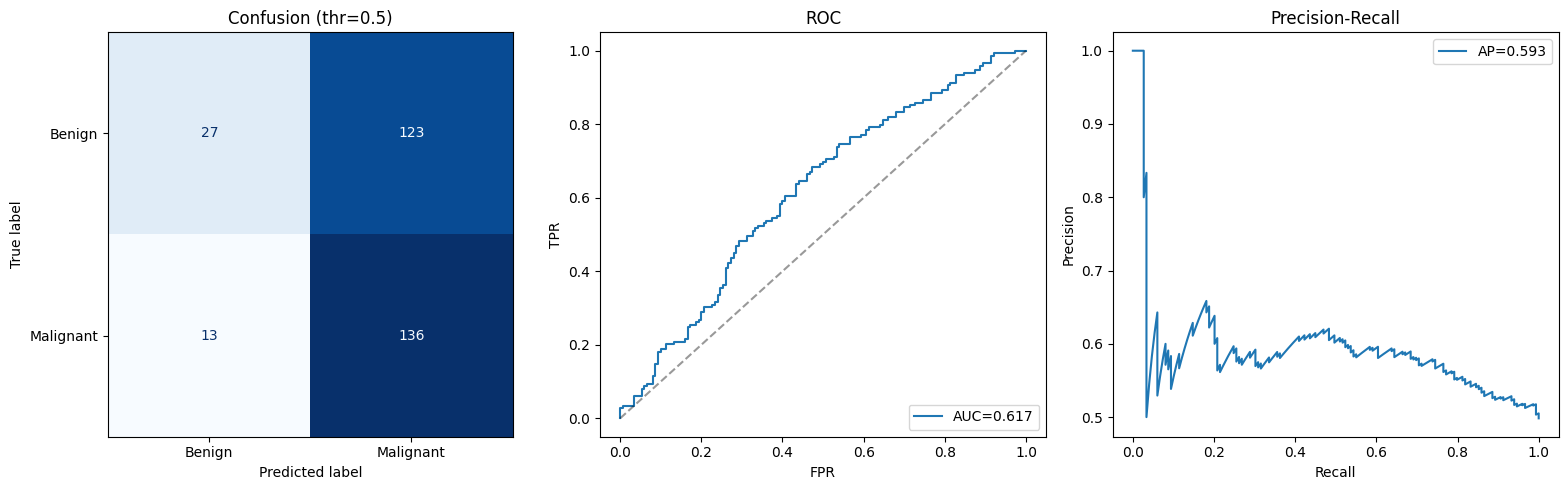

In [18]:
prec, rec, _ = precision_recall_curve(y_true, y_prob)
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ConfusionMatrixDisplay(confusion_matrix(y_true, (y_prob>=0.5).astype(int)),
                       display_labels=['Benign','Malignant']).plot(cmap='Blues', ax=ax[0], colorbar=False)
ax[0].set_title('Confusion (thr=0.5)')
ax[1].plot(fpr, tpr, label=f'AUC={auc:.3f}'); ax[1].plot([0,1],[0,1],'k--',alpha=.4)
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].set_title('ROC'); ax[1].legend(loc='lower right')
ax[2].plot(rec, prec, label=f'AP={ap:.3f}'); ax[2].set_xlabel('Recall'); ax[2].set_ylabel('Precision')
ax[2].set_title('Precision-Recall'); ax[2].legend()
plt.tight_layout(); plt.show()

In [19]:
best_fold = int(np.argmax(fold_val_auc))
mc_model = GatedAttentionMIL(DROPOUT_P, ATT_DIM).to(device)
mc_model.load_state_dict(torch.load(f'{WORK}/mil_fold{best_fold}.pth'))
mc_model.eval()
for m in mc_model.modules():
    if isinstance(m, nn.Dropout): m.train()

test_loader = DataLoader(BreastDataset(test_df, eval_tf), batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)
mc = np.zeros((MC_PASSES, len(test_df)), dtype=np.float32)
with torch.no_grad():
    for t in range(MC_PASSES):
        idx = 0
        for x, _ in test_loader:
            p = torch.sigmoid(mc_model(x.to(device))).cpu().numpy()
            mc[t, idx:idx+len(p)] = p; idx += len(p)

p_hat, p_std = mc.mean(0), mc.std(0)
entropy = -(p_hat*np.log(p_hat+1e-8) + (1-p_hat)*np.log(1-p_hat+1e-8))
mc_pred = (p_hat >= 0.5).astype(int)
correct = mc_pred == y_true
print(f'MC AUROC {roc_auc_score(y_true, p_hat):.4f}')
print(f'mean std  correct {p_std[correct].mean():.4f} | incorrect {p_std[~correct].mean():.4f}')
print(f'mean entropy correct {entropy[correct].mean():.4f} | incorrect {entropy[~correct].mean():.4f}')

MC AUROC 0.6028
mean std  correct 0.0477 | incorrect 0.0486
mean entropy correct 0.6736 | incorrect 0.6791


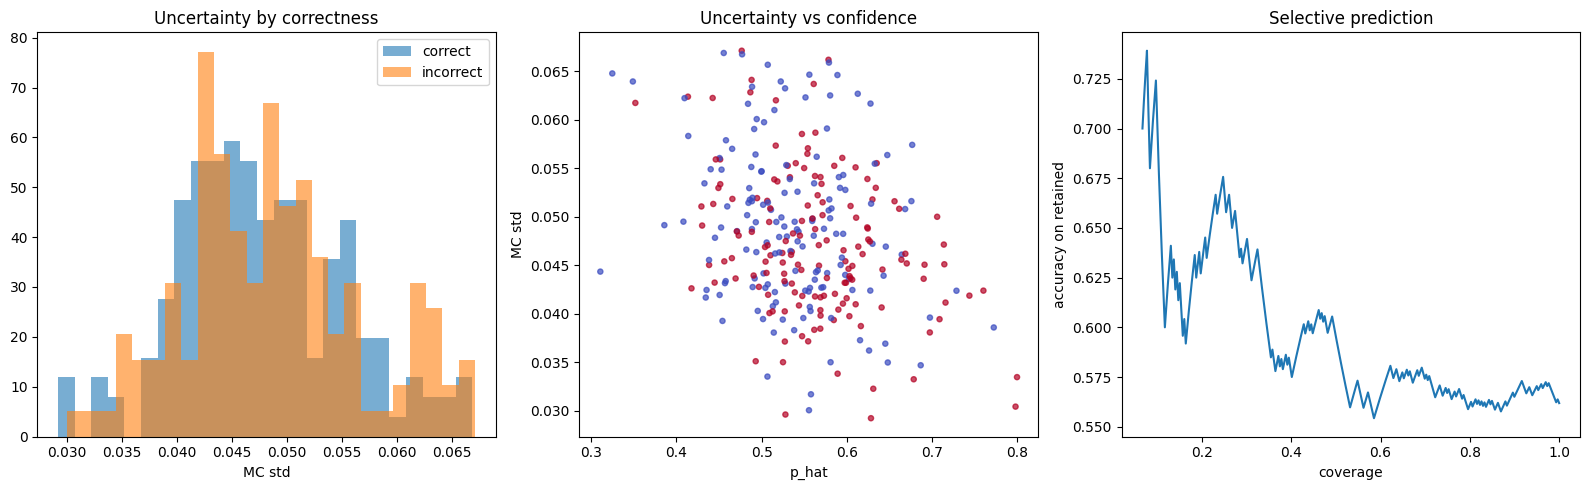

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].hist(p_std[correct], bins=25, alpha=.6, label='correct', density=True)
ax[0].hist(p_std[~correct], bins=25, alpha=.6, label='incorrect', density=True)
ax[0].set_xlabel('MC std'); ax[0].set_title('Uncertainty by correctness'); ax[0].legend()
ax[1].scatter(p_hat, p_std, c=y_true, cmap='coolwarm', s=14, alpha=.7)
ax[1].set_xlabel('p_hat'); ax[1].set_ylabel('MC std'); ax[1].set_title('Uncertainty vs confidence')
order = np.argsort(entropy); cov, accs = [], []
for kk in range(20, len(order)+1):
    keep = order[:kk]; cov.append(kk/len(order)); accs.append((mc_pred[keep]==y_true[keep]).mean())
ax[2].plot(cov, accs); ax[2].set_xlabel('coverage'); ax[2].set_ylabel('accuracy on retained')
ax[2].set_title('Selective prediction'); plt.tight_layout(); plt.show()

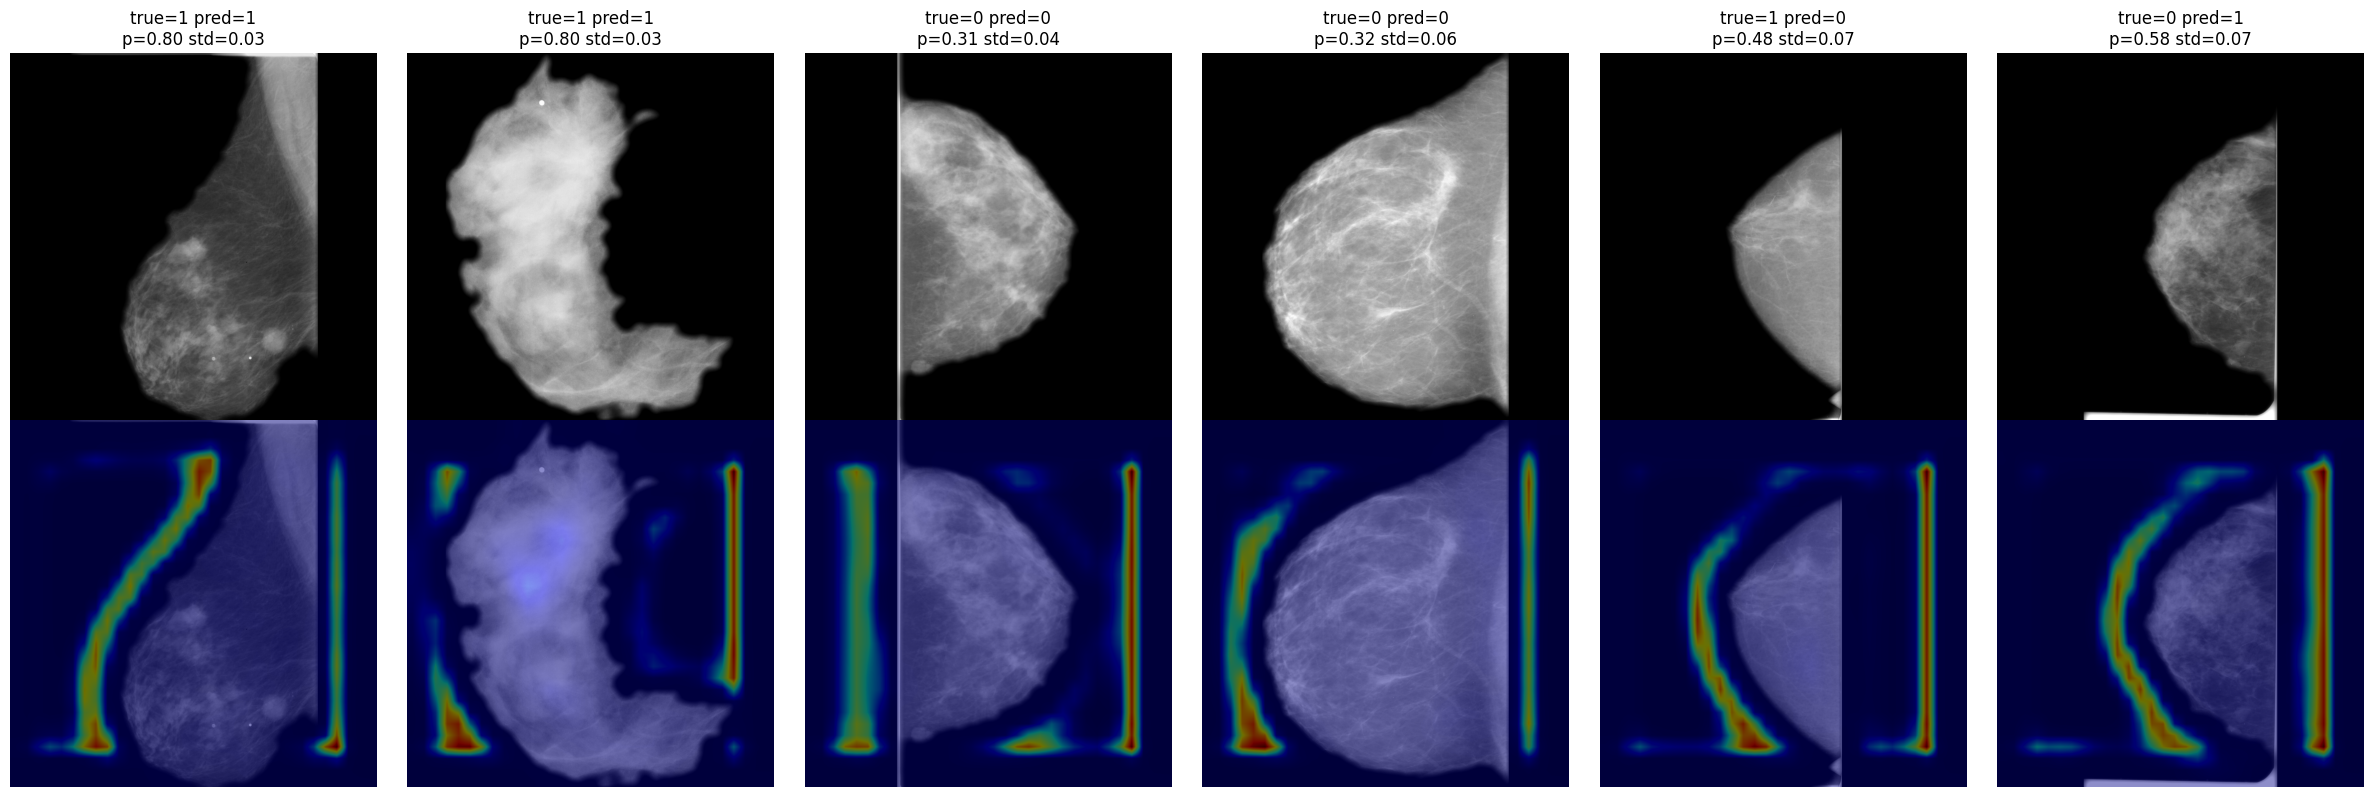

In [21]:
viz_model = GatedAttentionMIL(DROPOUT_P, ATT_DIM).to(device)
viz_model.load_state_dict(torch.load(f'{WORK}/mil_fold{best_fold}.pth'))
viz_model.eval()

tp = np.where((y_true==1)&(mc_pred==1))[0]; tn = np.where((y_true==0)&(mc_pred==0))[0]
err = np.where(mc_pred!=y_true)[0]
sel = list(tp[np.argsort(-p_hat[tp])[:2]]) + list(tn[np.argsort(p_hat[tn])[:2]]) \
    + list(err[np.argsort(-p_std[err])[:2]])

fig, ax = plt.subplots(2, len(sel), figsize=(4*len(sel), 8))
for j, i in enumerate(sel):
    row = test_df.iloc[i]
    pil = Image.open(row['filepath']).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    x = eval_tf(pil).unsqueeze(0).to(device)
    with torch.no_grad():
        logit, attn = viz_model(x, return_attn=True)
    heat = F.interpolate(attn.unsqueeze(1), size=(IMG_SIZE, IMG_SIZE), mode='bilinear',
                         align_corners=False).squeeze().cpu().numpy()
    heat = (heat - heat.min())/(heat.max()-heat.min()+1e-8)
    base = np.array(pil.convert('L'))
    ax[0, j].imshow(base, cmap='gray'); ax[0, j].axis('off')
    ax[0, j].set_title(f"true={int(row['label'])} pred={mc_pred[i]}\np={p_hat[i]:.2f} std={p_std[i]:.2f}")
    ax[1, j].imshow(base, cmap='gray'); ax[1, j].imshow(heat, cmap='jet', alpha=0.45); ax[1, j].axis('off')
ax[0,0].set_ylabel('input'); ax[1,0].set_ylabel('attention')
plt.tight_layout(); plt.show()